In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif, SelectKBest, chi2, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
import sklearn

df = pd.read_csv("D:\\education\\SLIIT\\2nd year\\1st semester\\IT2011AI ML\\Assignment\\Employee Attrition Prediction Dataset\\Employee-Attrition-Prediction-ML-Model\\results\\Outputs\\Final\\Employee Attrition Prediction Dataset.csv")

print("Shape:", df.shape)
df.head()

Shape: (74498, 24)


,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,...,Number of Dependents,Job Level,Company Size,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
0,8410,31,Male,19,Education,5390,Excellent,Medium,Average,2,...,0,Mid,Medium,89,No,No,No,Excellent,Medium,Stayed
1,64756,59,Female,4,Media,5534,Poor,High,Low,3,...,3,Mid,Medium,21,No,No,No,Fair,Low,Stayed
2,30257,24,Female,10,Healthcare,8159,Good,High,Low,0,...,3,Mid,Medium,74,No,No,No,Poor,Low,Stayed
3,65791,36,Female,7,Education,3989,Good,High,High,1,...,2,Mid,Small,50,Yes,No,No,Good,Medium,Stayed
4,65026,56,Male,41,Education,4821,Fair,Very High,Average,0,...,0,Senior,Medium,68,No,No,No,Fair,Medium,Stayed


## Handling Missing Data

In [2]:
# Check missing values count per column
missing_counts = df.isnull().sum()
print(missing_counts)

Employee ID                 0
Age                         0
Gender                      0
Years at Company            0
Job Role                    0
Monthly Income              0
Work-Life Balance           0
Job Satisfaction            0
Performance Rating          0
Number of Promotions        0
Overtime                    0
Distance from Home          0
Education Level             0
Marital Status              0
Number of Dependents        0
Job Level                   0
Company Size                0
Company Tenure              0
Remote Work                 0
Leadership Opportunities    0
Innovation Opportunities    0
Company Reputation          0
Employee Recognition        0
Attrition                   0
dtype: int64


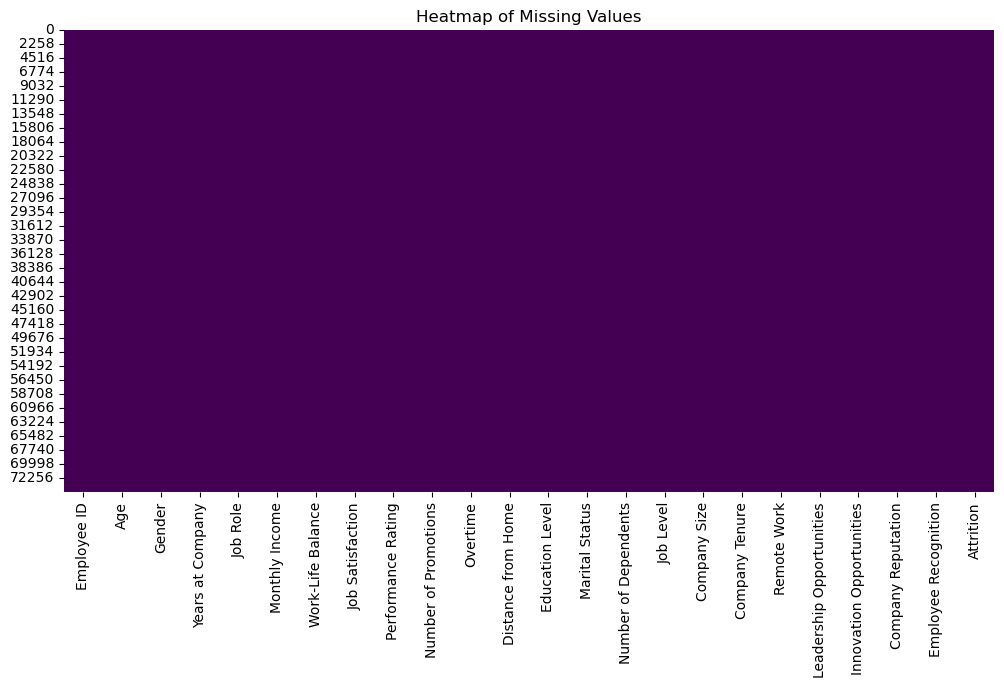

In [3]:
#Handling Missing Data
# Visualization: Heatmap of missing values
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Heatmap of Missing Values")
plt.show()

## Categorical Encoding

In [4]:
# Check data types
print(df.dtypes)

# Select categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print("Categorical columns:", categorical_cols)


Employee ID                  int64
Age                          int64
Gender                      object
Years at Company             int64
Job Role                    object
Monthly Income               int64
Work-Life Balance           object
Job Satisfaction            object
Performance Rating          object
Number of Promotions         int64
Overtime                    object
Distance from Home           int64
Education Level             object
Marital Status              object
Number of Dependents         int64
Job Level                   object
Company Size                object
Company Tenure               int64
Remote Work                 object
Leadership Opportunities    object
Innovation Opportunities    object
Company Reputation          object
Employee Recognition        object
Attrition                   object
dtype: object
Categorical columns: ['Gender', 'Job Role', 'Work-Life Balance', 'Job Satisfaction', 'Performance Rating', 'Overtime', 'Education Level', 'Marital

In [5]:
# Ordinal features (Label Encoding)
ordinal_features = ["Work-Life Balance","Job Satisfaction","Performance Rating","Education Leve","Company Reputation","Employee Recognition"]

#Label encoding
ordinal_mappings = {
    "Work-Life Balance": {"Poor": 1, "Fair": 2, "Good": 3, "Excellent": 4},
    "Job Satisfaction": {"Low": 1, "Medium": 2, "High": 3, "Very High": 4},
    "Performance Rating": {"Low": 1, "Below Average": 2, "Average": 3, "High": 4},
    "Education Level": {"High School": 1, "Associate Degree": 2, "Bachelorâ€™s Degree": 3,"Masterâ€™s Degree":4,"PhD":5},
    "Company Reputation": {"Poor": 1, "Fair": 2, "Good": 3, "Excellent": 4},
    "Employee Recognition": {"Low": 1, "Medium": 2, "High": 3, "Very High": 4}
}

for col, mapping in ordinal_mappings.items():
    df[col + '_Enc'] = df[col].map(mapping)
print("After encoding more columns shape:", df.shape)
df.head()

After encoding more columns shape: (74498, 30)


,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,...,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition,Work-Life Balance_Enc,Job Satisfaction_Enc,Performance Rating_Enc,Education Level_Enc,Company Reputation_Enc,Employee Recognition_Enc
0,8410,31,Male,19,Education,5390,Excellent,Medium,Average,2,...,No,Excellent,Medium,Stayed,4,2,3,2,4,2
1,64756,59,Female,4,Media,5534,Poor,High,Low,3,...,No,Fair,Low,Stayed,1,3,1,4,2,1
2,30257,24,Female,10,Healthcare,8159,Good,High,Low,0,...,No,Poor,Low,Stayed,3,3,1,3,1,1
3,65791,36,Female,7,Education,3989,Good,High,High,1,...,No,Good,Medium,Stayed,3,3,4,1,3,2
4,65026,56,Male,41,Education,4821,Fair,Very High,Average,0,...,No,Fair,Medium,Stayed,2,4,3,1,2,2


In [6]:
# Binary columns (Yes/No) 
binary_features = ["Overtime","Remote Work","Leadership Opportunities","Innovation Opportunities"]
# Binary encoding (Label encoding)
for col in binary_features:
    df[col + '_Enc'] = df[col].map({'No': 0, 'Yes': 1})
print("After encoding more columns shape:", df.shape)
df.head()

After encoding more columns shape: (74498, 34)


,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,...,Work-Life Balance_Enc,Job Satisfaction_Enc,Performance Rating_Enc,Education Level_Enc,Company Reputation_Enc,Employee Recognition_Enc,Overtime_Enc,Remote Work_Enc,Leadership Opportunities_Enc,Innovation Opportunities_Enc
0,8410,31,Male,19,Education,5390,Excellent,Medium,Average,2,...,4,2,3,2,4,2,0,0,0,0
1,64756,59,Female,4,Media,5534,Poor,High,Low,3,...,1,3,1,4,2,1,0,0,0,0
2,30257,24,Female,10,Healthcare,8159,Good,High,Low,0,...,3,3,1,3,1,1,0,0,0,0
3,65791,36,Female,7,Education,3989,Good,High,High,1,...,3,3,4,1,3,2,0,1,0,0
4,65026,56,Male,41,Education,4821,Fair,Very High,Average,0,...,2,4,3,1,2,2,1,0,0,0


In [7]:
# Target column
target_col = "Attrition"
# Target encoding(Label encoding)
df["Attrition_Enc"]=df[target_col].map({"Stayed": 1, "Left": 0})
df.head()

,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,...,Job Satisfaction_Enc,Performance Rating_Enc,Education Level_Enc,Company Reputation_Enc,Employee Recognition_Enc,Overtime_Enc,Remote Work_Enc,Leadership Opportunities_Enc,Innovation Opportunities_Enc,Attrition_Enc
0,8410,31,Male,19,Education,5390,Excellent,Medium,Average,2,...,2,3,2,4,2,0,0,0,0,1
1,64756,59,Female,4,Media,5534,Poor,High,Low,3,...,3,1,4,2,1,0,0,0,0,1
2,30257,24,Female,10,Healthcare,8159,Good,High,Low,0,...,3,1,3,1,1,0,0,0,0,1
3,65791,36,Female,7,Education,3989,Good,High,High,1,...,3,4,1,3,2,0,1,0,0,1
4,65026,56,Male,41,Education,4821,Fair,Very High,Average,0,...,4,3,1,2,2,1,0,0,0,1


In [8]:
# Nominal features 
nominal_features =["Gender","Job Role","Marital Status","Company Size","Job Level"]

# One-Hot Encoding encoding
df = pd.get_dummies(df, columns=nominal_features, drop_first=True)

print("After encoding more columns shape:", df.shape)
df.head()

After encoding more columns shape: (74498, 41)


,Employee ID,Age,Years at Company,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,Overtime,Distance from Home,...,Job Role_Finance,Job Role_Healthcare,Job Role_Media,Job Role_Technology,Marital Status_Married,Marital Status_Single,Company Size_Medium,Company Size_Small,Job Level_Mid,Job Level_Senior
0,8410,31,19,5390,Excellent,Medium,Average,2,No,22,...,False,False,False,False,True,False,True,False,True,False
1,64756,59,4,5534,Poor,High,Low,3,No,21,...,False,False,True,False,False,False,True,False,True,False
2,30257,24,10,8159,Good,High,Low,0,No,11,...,False,True,False,False,True,False,True,False,True,False
3,65791,36,7,3989,Good,High,High,1,No,27,...,False,False,False,False,False,True,False,True,True,False
4,65026,56,41,4821,Fair,Very High,Average,0,Yes,71,...,False,False,False,False,False,False,True,False,False,True


In [9]:
print(df.columns.tolist())

['Employee ID', 'Age', 'Years at Company', 'Monthly Income', 'Work-Life Balance', 'Job Satisfaction', 'Performance Rating', 'Number of Promotions', 'Overtime', 'Distance from Home', 'Education Level', 'Number of Dependents', 'Company Tenure', 'Remote Work', 'Leadership Opportunities', 'Innovation Opportunities', 'Company Reputation', 'Employee Recognition', 'Attrition', 'Work-Life Balance_Enc', 'Job Satisfaction_Enc', 'Performance Rating_Enc', 'Education Level_Enc', 'Company Reputation_Enc', 'Employee Recognition_Enc', 'Overtime_Enc', 'Remote Work_Enc', 'Leadership Opportunities_Enc', 'Innovation Opportunities_Enc', 'Attrition_Enc', 'Gender_Male', 'Job Role_Finance', 'Job Role_Healthcare', 'Job Role_Media', 'Job Role_Technology', 'Marital Status_Married', 'Marital Status_Single', 'Company Size_Medium', 'Company Size_Small', 'Job Level_Mid', 'Job Level_Senior']


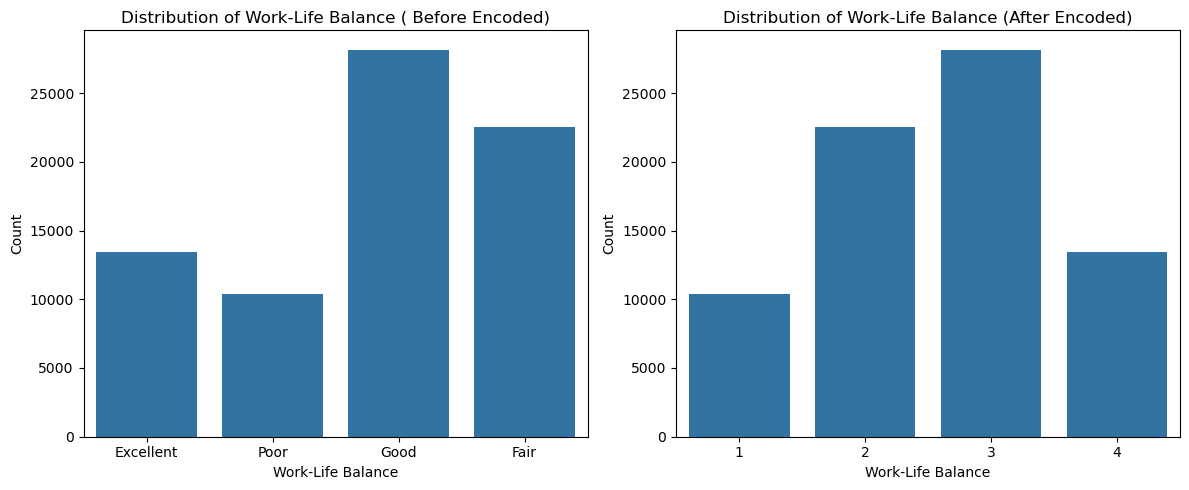

In [10]:
#Visualization for Label encoding
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.countplot(x="Work-Life Balance", data=df)
plt.title("Distribution of Work-Life Balance ( Before Encoded)")
plt.xlabel("Work-Life Balance")
plt.ylabel("Count")

plt.subplot(1,2,2)
sns.countplot(x="Work-Life Balance_Enc", data=df)
plt.title("Distribution of Work-Life Balance (After Encoded)")
plt.xlabel("Work-Life Balance")
plt.ylabel("Count")

plt.tight_layout()
plt.show()


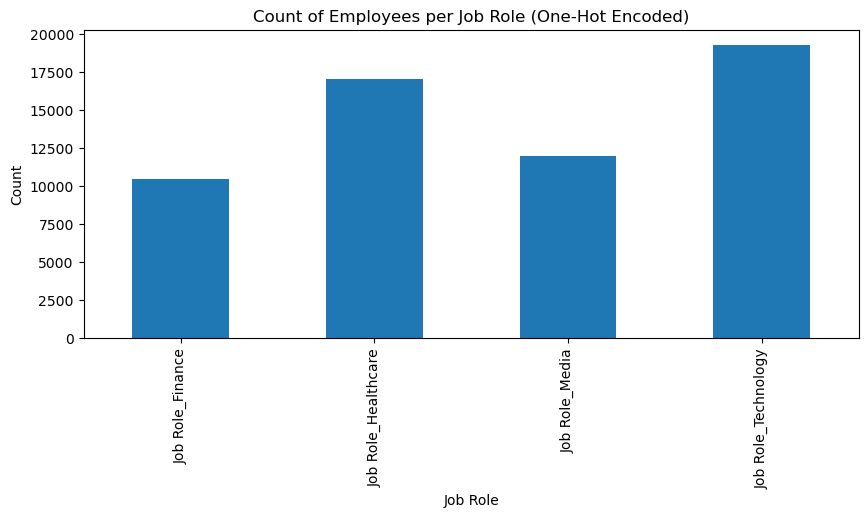

In [11]:
#Visualization for One-Hot Encodeing 
job_role_cols = [col for col in df.columns if 'Job Role_' in col]

plt.figure(figsize=(10,4))
df[job_role_cols].sum().plot(kind='bar')
plt.title("Count of Employees per Job Role (One-Hot Encoded)")
plt.xlabel("Job Role")
plt.ylabel("Count")
plt.show()

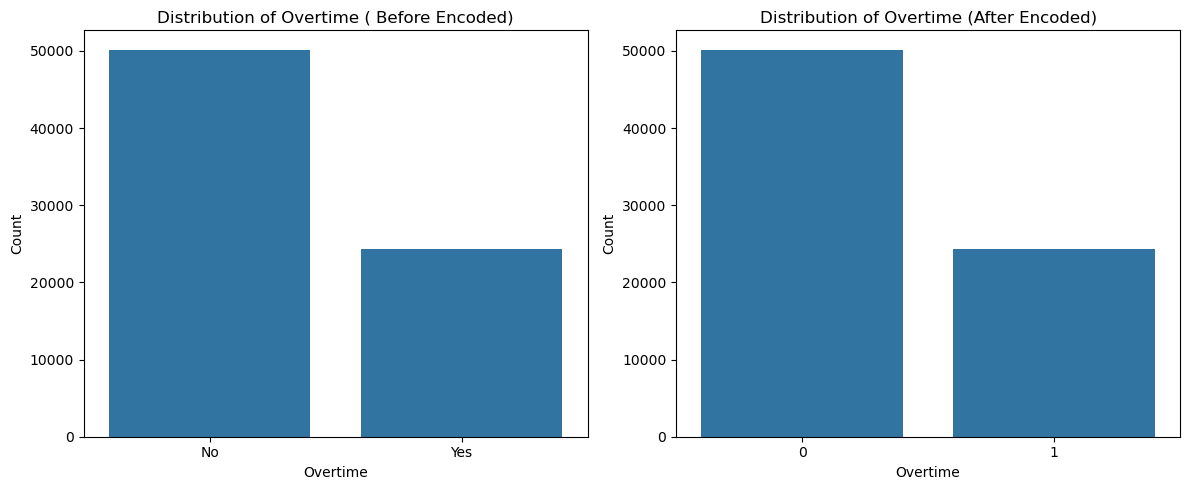

In [12]:
#Visualization for Binary encoding
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.countplot(x="Overtime", data=df)
plt.title("Distribution of Overtime ( Before Encoded)")
plt.xlabel("Overtime")
plt.ylabel("Count")

plt.subplot(1,2,2)
sns.countplot(x="Overtime_Enc", data=df)
plt.title("Distribution of Overtime (After Encoded)")
plt.xlabel("Overtime")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

## Outliers

In [13]:
df.info()
df.describe() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74498 entries, 0 to 74497
Data columns (total 41 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   Employee ID                   74498 non-null  int64 
 1   Age                           74498 non-null  int64 
 2   Years at Company              74498 non-null  int64 
 3   Monthly Income                74498 non-null  int64 
 4   Work-Life Balance             74498 non-null  object
 5   Job Satisfaction              74498 non-null  object
 6   Performance Rating            74498 non-null  object
 7   Number of Promotions          74498 non-null  int64 
 8   Overtime                      74498 non-null  object
 9   Distance from Home            74498 non-null  int64 
 10  Education Level               74498 non-null  object
 11  Number of Dependents          74498 non-null  int64 
 12  Company Tenure                74498 non-null  int64 
 13  Remote Work     

,Employee ID,Age,Years at Company,Monthly Income,Number of Promotions,Distance from Home,Number of Dependents,Company Tenure,Work-Life Balance_Enc,Job Satisfaction_Enc,Performance Rating_Enc,Education Level_Enc,Company Reputation_Enc,Employee Recognition_Enc,Overtime_Enc,Remote Work_Enc,Leadership Opportunities_Enc,Innovation Opportunities_Enc,Attrition_Enc
count,74498.000000,74498.000000,74498.000000,74498.000000,74498.000000,74498.000000,74498.000000,74498.000000,74498.000000,74498.000000,74498.000000,74498.000000,74498.000000,74498.000000,74498.000000,74498.000000,74498.000000,74498.000000,74498.000000
mean,37249.500000,38.529746,15.721603,7299.379514,0.832935,49.991584,1.650326,55.727456,2.599251,2.804666,2.950482,2.659669,2.495235,1.949958,0.326734,0.190582,0.049035,0.162474,0.525222
std,21505.864514,12.083456,11.223744,2152.508566,0.995289,28.513611,1.553633,25.399349,0.937763,0.873040,0.739925,1.152955,0.924574,0.917174,0.469022,0.392763,0.215942,0.368888,0.499367
min,1.000000,18.000000,1.000000,1226.000000,0.000000,1.000000,0.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,18625.250000,28.000000,7.000000,5652.000000,0.000000,25.000000,0.000000,36.000000,2.000000,2.000000,3.000000,2.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,37249.500000,39.000000,13.000000,7348.000000,1.000000,50.000000,1.000000,56.000000,3.000000,3.000000,3.000000,3.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,55873.750000,49.000000,23.000000,8876.000000,2.000000,75.000000,3.000000,76.000000,3.000000,3.000000,3.000000,4.000000,3.000000,3.000000,1.000000,0.000000,0.000000,0.000000,1.000000
max,74498.000000,59.000000,51.000000,16149.000000,4.000000,99.000000,6.000000,128.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [14]:
# Select numeric columns for outlier detection
numeric_cols = ["Age", "Years at Company", "Monthly Income",
                "Number of Promotions", "Distance from Home",
                "Number of Dependents", "Company Tenure"]

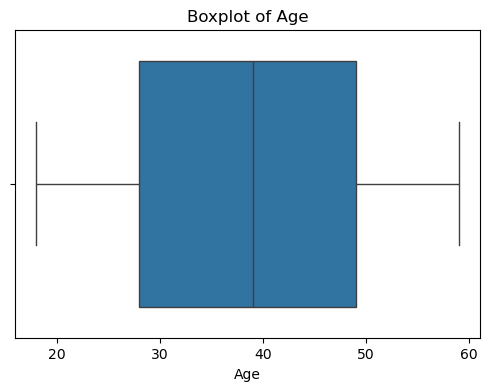

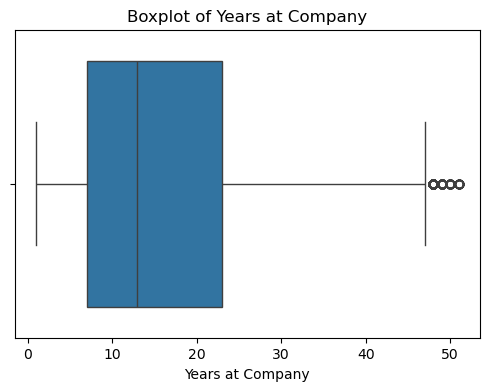

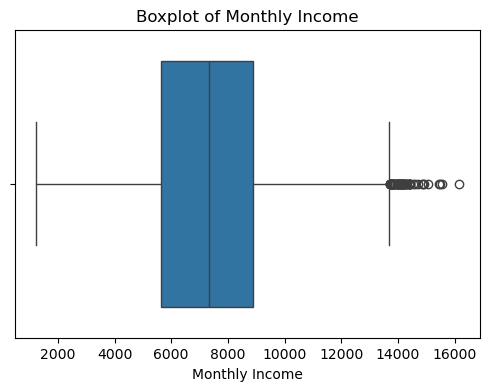

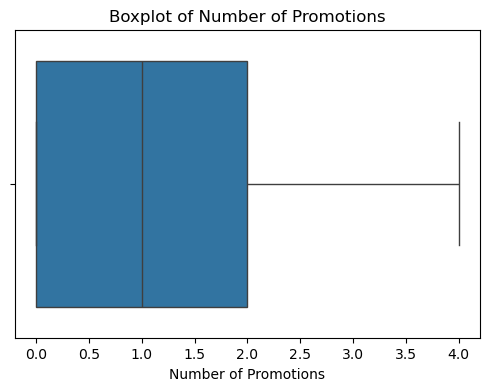

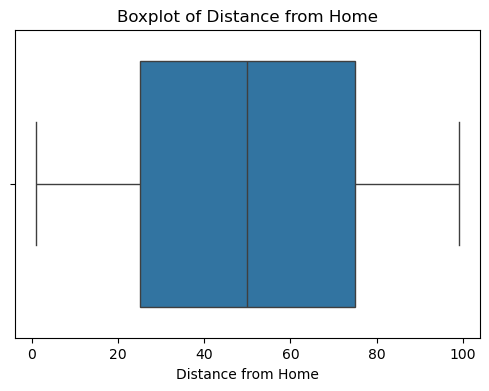

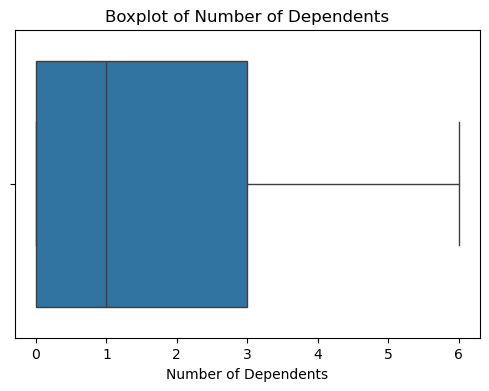

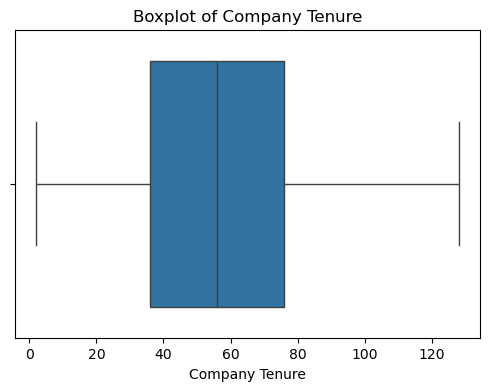

In [15]:
# Visualize with boxplots
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [16]:
# Detect outliers using IQR method
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers")

Age: 0 outliers
Years at Company: 338 outliers
Monthly Income: 65 outliers
Number of Promotions: 0 outliers
Distance from Home: 0 outliers
Number of Dependents: 0 outliers
Company Tenure: 0 outliers


In [17]:
# Remove outliers
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower) & (df[col] <= upper)]

print("Shape after removing outliers:", df.shape)

Shape after removing outliers: (74095, 41)


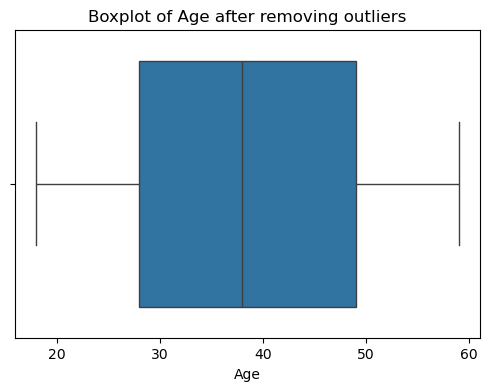

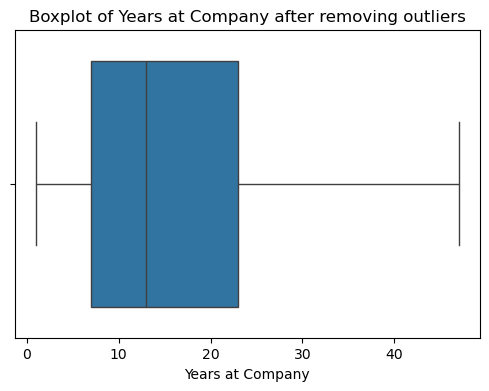

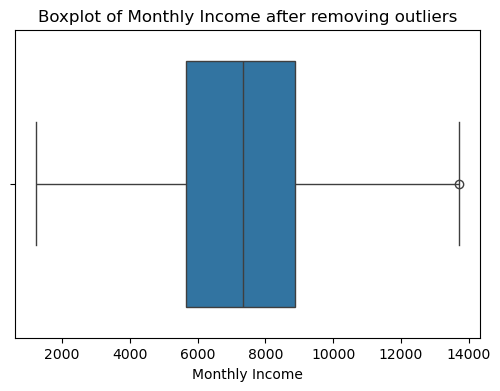

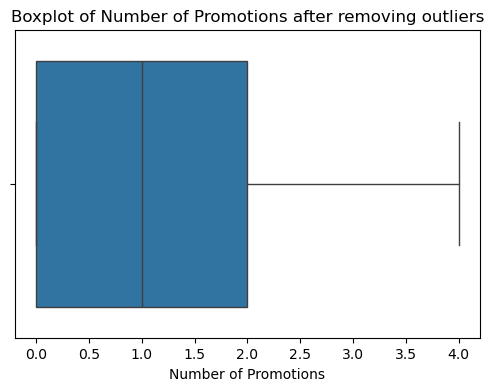

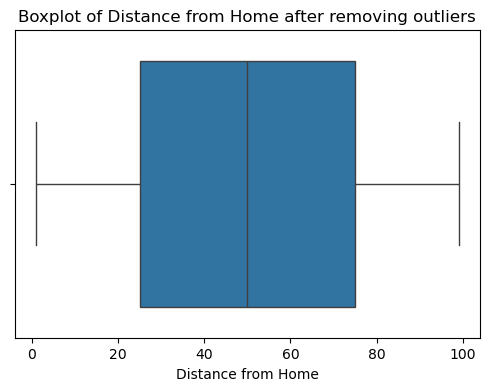

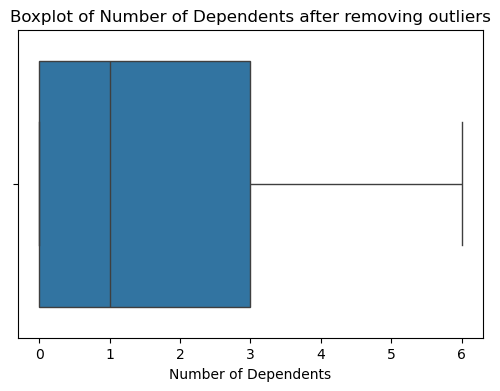

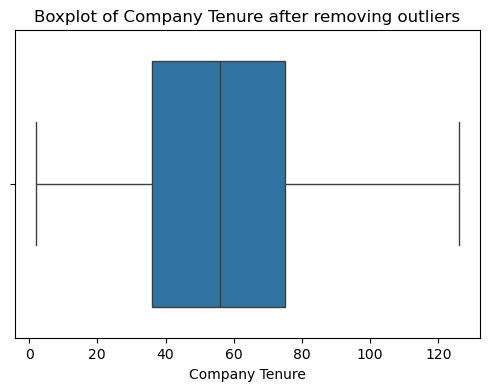

In [18]:
# Boxplots AFTER removing outliers
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col} after removing outliers")
    plt.show()

In [19]:
print("Shape:", df.shape)
df.head()

Shape: (74095, 41)


,Employee ID,Age,Years at Company,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,Overtime,Distance from Home,...,Job Role_Finance,Job Role_Healthcare,Job Role_Media,Job Role_Technology,Marital Status_Married,Marital Status_Single,Company Size_Medium,Company Size_Small,Job Level_Mid,Job Level_Senior
0,8410,31,19,5390,Excellent,Medium,Average,2,No,22,...,False,False,False,False,True,False,True,False,True,False
1,64756,59,4,5534,Poor,High,Low,3,No,21,...,False,False,True,False,False,False,True,False,True,False
2,30257,24,10,8159,Good,High,Low,0,No,11,...,False,True,False,False,True,False,True,False,True,False
3,65791,36,7,3989,Good,High,High,1,No,27,...,False,False,False,False,False,True,False,True,True,False
4,65026,56,41,4821,Fair,Very High,Average,0,Yes,71,...,False,False,False,False,False,False,True,False,False,True


## Normalization

In [20]:
# Select numeric columns
numeric_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
print("Numeric columns:", numeric_cols)

Numeric columns: ['Employee ID', 'Age', 'Years at Company', 'Monthly Income', 'Number of Promotions', 'Distance from Home', 'Number of Dependents', 'Company Tenure', 'Work-Life Balance_Enc', 'Job Satisfaction_Enc', 'Performance Rating_Enc', 'Education Level_Enc', 'Company Reputation_Enc', 'Employee Recognition_Enc', 'Overtime_Enc', 'Remote Work_Enc', 'Leadership Opportunities_Enc', 'Innovation Opportunities_Enc', 'Attrition_Enc']


In [21]:
scaler = StandardScaler()

# Apply to selected columns
scale_cols = ["Age","Years at Company", "Monthly Income", "Number of Promotions", "Distance from Home", "Number of Dependents", "Company Tenure"]
df[scale_cols] = scaler.fit_transform(df[scale_cols])

df.head()

,Employee ID,Age,Years at Company,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,Overtime,Distance from Home,...,Job Role_Finance,Job Role_Healthcare,Job Role_Media,Job Role_Technology,Marital Status_Married,Marital Status_Single,Company Size_Medium,Company Size_Small,Job Level_Mid,Job Level_Senior
0,8410,-0.618109,0.311112,-0.887991,Excellent,Medium,Average,1.172461,No,-0.981849,...,False,False,False,False,True,False,True,False,True,False
1,64756,1.707605,-1.049752,-0.820817,Poor,High,Low,2.177174,No,-1.016913,...,False,False,True,False,False,False,True,False,True,False
2,30257,-1.199537,-0.505406,0.403699,Good,High,Low,-0.836965,No,-1.367549,...,False,True,False,False,True,False,True,False,True,False
3,65791,-0.202803,-0.777579,-1.541533,Good,High,High,0.167748,No,-0.806531,...,False,False,False,False,False,True,False,True,True,False
4,65026,1.458421,2.307046,-1.153419,Fair,Very High,Average,-0.836965,Yes,0.736268,...,False,False,False,False,False,False,True,False,False,True


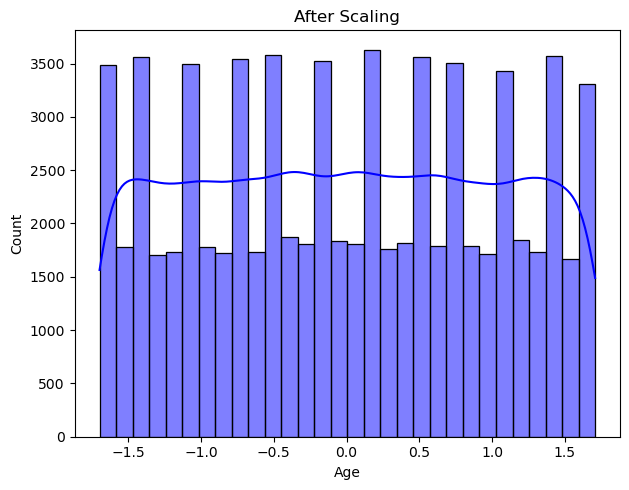

In [22]:
#Age after scaling
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df["Age"], bins=30, kde=True, color="blue")
plt.title("After Scaling")

plt.tight_layout()
plt.show()

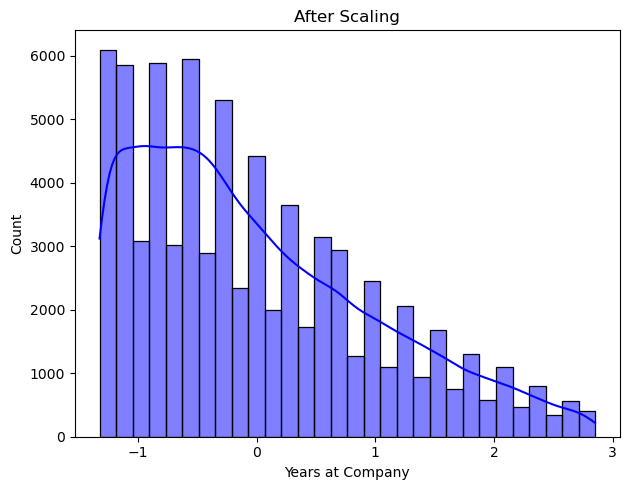

In [23]:
#Years at Company distribution after scaling
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df["Years at Company"], bins=30, kde=True, color="blue")
plt.title("After Scaling")

plt.tight_layout()
plt.show()


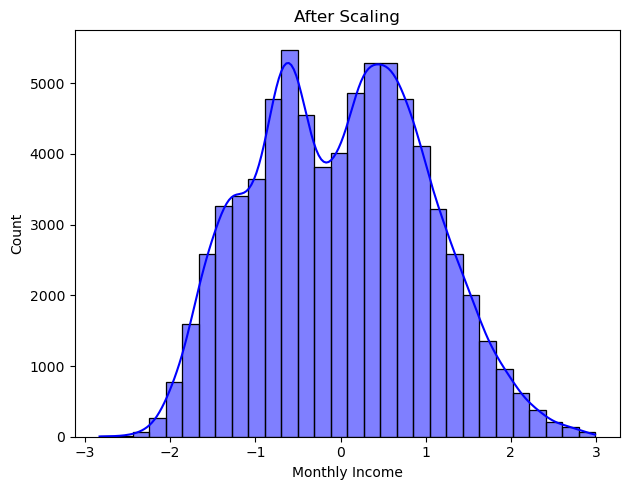

In [24]:
# Monthly Income distribution after scaling
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df["Monthly Income"], bins=30, kde=True, color="blue")
plt.title("After Scaling")

plt.tight_layout()
plt.show()


## Feature Selection

In [25]:
#target
y = df["Attrition_Enc"]

cols_to_drop = ["Employee ID"] 
df.drop(columns=[col for col in cols_to_drop if col in df.columns], inplace=True)

print(df.columns.tolist())

['Age', 'Years at Company', 'Monthly Income', 'Work-Life Balance', 'Job Satisfaction', 'Performance Rating', 'Number of Promotions', 'Overtime', 'Distance from Home', 'Education Level', 'Number of Dependents', 'Company Tenure', 'Remote Work', 'Leadership Opportunities', 'Innovation Opportunities', 'Company Reputation', 'Employee Recognition', 'Attrition', 'Work-Life Balance_Enc', 'Job Satisfaction_Enc', 'Performance Rating_Enc', 'Education Level_Enc', 'Company Reputation_Enc', 'Employee Recognition_Enc', 'Overtime_Enc', 'Remote Work_Enc', 'Leadership Opportunities_Enc', 'Innovation Opportunities_Enc', 'Attrition_Enc', 'Gender_Male', 'Job Role_Finance', 'Job Role_Healthcare', 'Job Role_Media', 'Job Role_Technology', 'Marital Status_Married', 'Marital Status_Single', 'Company Size_Medium', 'Company Size_Small', 'Job Level_Mid', 'Job Level_Senior']


In [26]:
# Drop original target and raw categorical columns
exclude_cols = ['Attrition', 'Attrition_Enc', 
                'Work-Life Balance', 'Job Satisfaction', 'Performance Rating',
                'Education Level', 'Company Reputation', 'Employee Recognition',
                'Overtime', 'Remote Work', 'Leadership Opportunities', 'Innovation Opportunities']

X = df.drop(columns=[col for col in exclude_cols if col in df.columns])

print("Final X shape:", X.shape)
print("Columns in X:", X.columns.tolist())
X.head()

Final X shape: (74095, 28)
Columns in X: ['Age', 'Years at Company', 'Monthly Income', 'Number of Promotions', 'Distance from Home', 'Number of Dependents', 'Company Tenure', 'Work-Life Balance_Enc', 'Job Satisfaction_Enc', 'Performance Rating_Enc', 'Education Level_Enc', 'Company Reputation_Enc', 'Employee Recognition_Enc', 'Overtime_Enc', 'Remote Work_Enc', 'Leadership Opportunities_Enc', 'Innovation Opportunities_Enc', 'Gender_Male', 'Job Role_Finance', 'Job Role_Healthcare', 'Job Role_Media', 'Job Role_Technology', 'Marital Status_Married', 'Marital Status_Single', 'Company Size_Medium', 'Company Size_Small', 'Job Level_Mid', 'Job Level_Senior']


,Age,Years at Company,Monthly Income,Number of Promotions,Distance from Home,Number of Dependents,Company Tenure,Work-Life Balance_Enc,Job Satisfaction_Enc,Performance Rating_Enc,...,Job Role_Finance,Job Role_Healthcare,Job Role_Media,Job Role_Technology,Marital Status_Married,Marital Status_Single,Company Size_Medium,Company Size_Small,Job Level_Mid,Job Level_Senior
0,-0.618109,0.311112,-0.887991,1.172461,-0.981849,-1.062324,1.320606,4,2,3,...,False,False,False,False,True,False,True,False,True,False
1,1.707605,-1.049752,-0.820817,2.177174,-1.016913,0.868460,-1.365803,1,3,1,...,False,False,True,False,False,False,True,False,True,False
2,-1.199537,-0.505406,0.403699,-0.836965,-1.367549,0.868460,0.728016,3,3,1,...,False,True,False,False,True,False,True,False,True,False
3,-0.202803,-0.777579,-1.541533,0.167748,-0.806531,0.224865,-0.220128,3,3,4,...,False,False,False,False,False,True,False,True,True,False
4,1.458421,2.307046,-1.153419,-0.836965,0.736268,-1.062324,0.490980,2,4,3,...,False,False,False,False,False,False,True,False,False,True


Top 10 features by Mutual Information:
 Marital Status_Single     0.040750
Job Level_Senior          0.040307
Marital Status_Married    0.032587
Remote Work_Enc           0.024814
Work-Life Balance_Enc     0.022061
Company Reputation_Enc    0.011336
Gender_Male               0.011106
Number of Promotions      0.010417
Company Size_Medium       0.007740
Number of Dependents      0.007652
dtype: float64


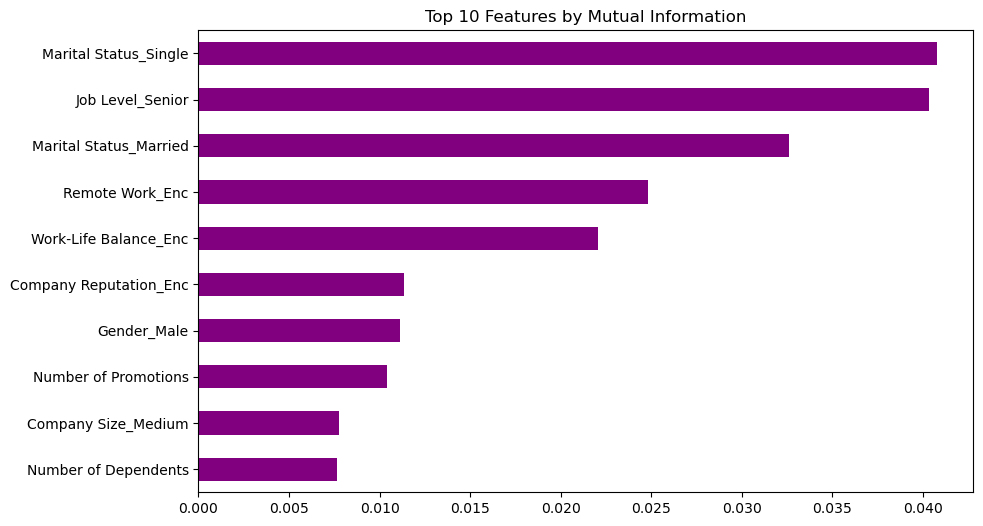

In [27]:
# Mutual Information Scores
mi_scores = mutual_info_classif(X, y, random_state=42)
mi_series = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

# Show top 10 features
print("Top 10 features by Mutual Information:\n", mi_series.head(10))

# Visualization
plt.figure(figsize=(10,6))
mi_series.head(10).plot(kind="barh", color="purple")
plt.title("Top 10 Features by Mutual Information")
plt.gca().invert_yaxis()
plt.show()

Top 10 features (Chi-Square): ['Number of Promotions', 'Number of Dependents', 'Work-Life Balance_Enc', 'Company Reputation_Enc', 'Overtime_Enc', 'Remote Work_Enc', 'Gender_Male', 'Marital Status_Married', 'Marital Status_Single', 'Job Level_Senior']


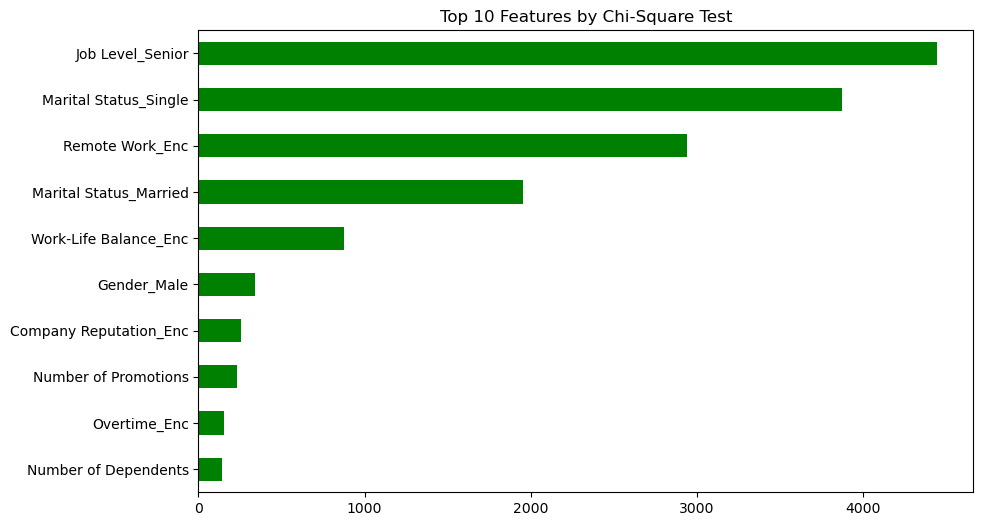

In [28]:
chi2_selector = SelectKBest(score_func=chi2, k=10)
chi2_selector.fit(abs(X), y) 
chi2_features = X.columns[chi2_selector.get_support()].tolist()

print("Top 10 features (Chi-Square):", chi2_features)

chi2_scores = pd.Series(chi2_selector.scores_, index=X.columns)
chi2_scores.nlargest(10).plot(kind='barh', figsize=(10,6), color="green")
plt.title("Top 10 Features by Chi-Square Test")
plt.gca().invert_yaxis()
plt.show()


Top 10 features (ANOVA F-test): ['Number of Promotions', 'Distance from Home', 'Number of Dependents', 'Work-Life Balance_Enc', 'Company Reputation_Enc', 'Remote Work_Enc', 'Gender_Male', 'Marital Status_Married', 'Marital Status_Single', 'Job Level_Senior']


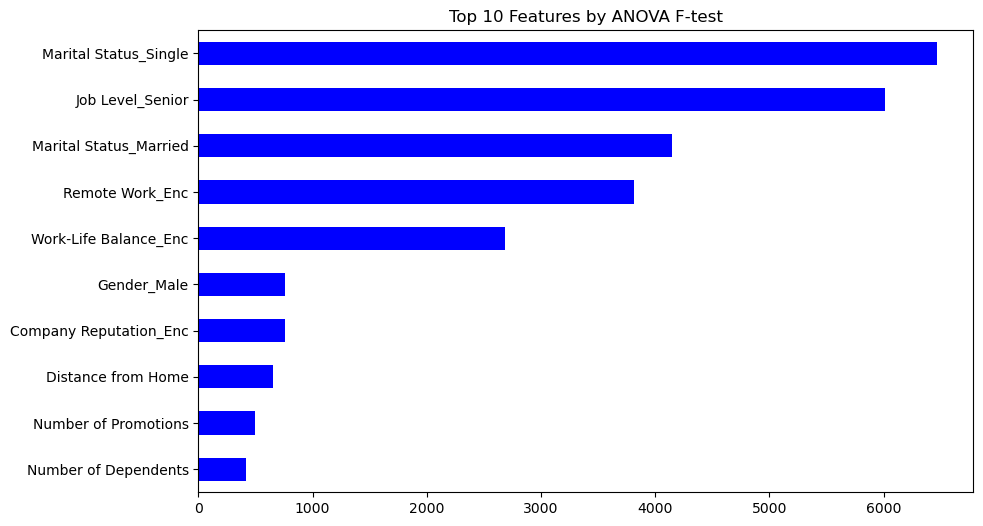

In [29]:
f_selector = SelectKBest(score_func=f_classif, k=10)
f_selector.fit(X, y)
f_features = X.columns[f_selector.get_support()].tolist()

print("Top 10 features (ANOVA F-test):", f_features)

f_scores = pd.Series(f_selector.scores_, index=X.columns)
f_scores.nlargest(10).plot(kind='barh', figsize=(10,6), color="blue")
plt.title("Top 10 Features by ANOVA F-test")
plt.gca().invert_yaxis()
plt.show()

Top 10 features (Random Forest):
 Distance from Home       0.083868
Monthly Income           0.080661
Company Tenure           0.075442
Job Level_Senior         0.074176
Age                      0.069280
Years at Company         0.068295
Marital Status_Single    0.059309
Work-Life Balance_Enc    0.052981
Remote Work_Enc          0.048768
Number of Dependents     0.041410
dtype: float64


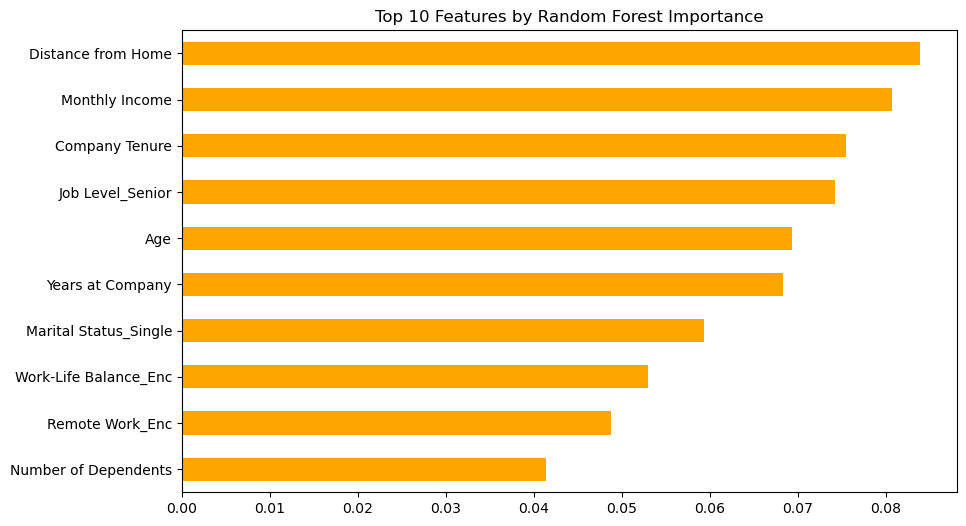

In [30]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

# Feature importances
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

print("Top 10 features (Random Forest):\n", importances.head(10))

# Visualization
plt.figure(figsize=(10,6))
importances.head(10).plot(kind="barh", color="orange")
plt.title("Top 10 Features by Random Forest Importance")
plt.gca().invert_yaxis()
plt.show()

## Dimensionality Reduction

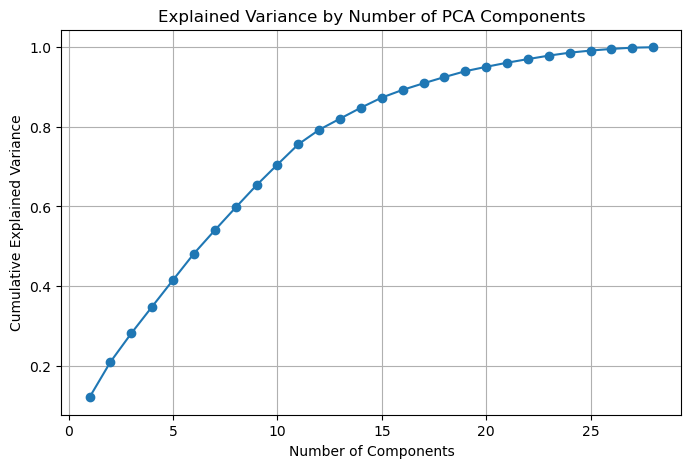

In [31]:
pca = PCA(n_components=None)
pca.fit(X)

# Cumulative variance explained
plt.figure(figsize=(8,5))
plt.plot(range(1, len(pca.explained_variance_ratio_)+1),
         pca.explained_variance_ratio_.cumsum(), marker="o")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance by Number of PCA Components")
plt.grid(True)
plt.show()


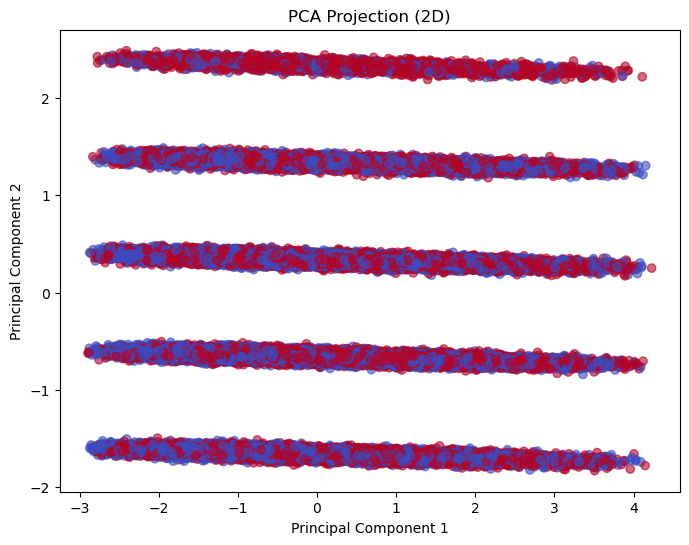

Explained variance ratio (2 PCs): [0.12075652 0.08872845]


In [32]:
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap="coolwarm", alpha=0.6)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection (2D)")
plt.show()

print("Explained variance ratio (2 PCs):", pca_2d.explained_variance_ratio_)


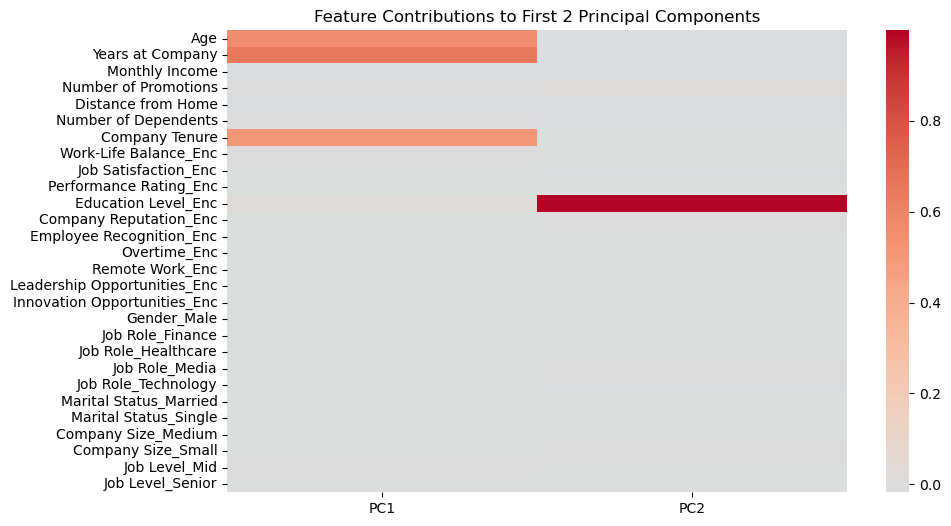

In [33]:
# PCA component loadings
loadings = pd.DataFrame(pca_2d.components_.T,
                        columns=["PC1", "PC2"],
                        index=X.columns)

plt.figure(figsize=(10,6))
sns.heatmap(loadings, cmap="coolwarm", center=0)
plt.title("Feature Contributions to First 2 Principal Components")
plt.show()


In [34]:
output_path = "D:\\education\\SLIIT\\2nd year\\1st semester\\IT2011AI ML\\Assignment\\Employee Attrition Prediction Dataset\\Employee-Attrition-Prediction-ML-Model\\results\\Outputs\\Final\\Employee Attrition Prediction Dataset.csv"
df.to_csv(output_path, index=False)